# SPEC 04 — Functional Subclass Analysis of LIN28A Direct Translational Repression Candidates

In [ ]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os, re

BASE    = '..'
S5_FULL = f'{BASE}/data/processed/table_s5_cleaned.csv'
S6_PATH = f'{BASE}/data/supplementary_tables/1-s2.0-S0092867412012342-mmc6.xls'
A_CSV   = f'{BASE}/results/tables/03_direct_candidates_threshold_A.csv'
B_CSV   = f'{BASE}/results/tables/03_direct_candidates_threshold_B.csv'
OUT_T   = f'{BASE}/results/tables'
OUT_F   = f'{BASE}/results/figures'
OUT_N   = f'{BASE}/notes'

ribo_col = 'Ribosome density change (log2)'
rna_col  = 'RNA-seq mRNA change upon Lin28a KD (log2)'
fdr_col  = 'CLIP-seq FDR'
clip_col = 'mean_CLIP_enrichment'


## 0. Environment check

In [ ]:
import sys
print(f'Python: {sys.version}')
print(f'pandas: {pd.__version__}, numpy: {np.__version__}, matplotlib: {matplotlib.__version__}')


## 1. Table S6 reference inspection

In [ ]:
import xlrd
s6 = pd.read_excel(S6_PATH, sheet_name=0, skiprows=1)
s6.columns = [c.strip("'") for c in s6.columns]
s6['GO term'] = s6['GO term'].astype(str).str.strip("'")
print(f'Table S6 shape: {s6.shape}')
print('Columns:', list(s6.columns))
print()

kws = ['endoplasmic reticulum','membrane','secretory','lumen','golgi','cell surface','extracellular']
pat = '|'.join(kws)
hits = s6[s6['GO term'].str.lower().str.contains(pat, na=False)]
print(f'Relevant GO terms: {len(hits)}')
print(hits[['GO term','CLIP-seq FDR','RPF\nFDR']].head(12).to_string(index=False))
print('\nNOTE: Table S6 is GO-level only. Cannot map individual GO terms to candidate genes.')


## 2. Load candidate tables and create group labels

In [ ]:
df_A = pd.read_csv(A_CSV)
df_B = pd.read_csv(B_CSV)
accA, accB = set(df_A['Accession']), set(df_B['Accession'])
overlap = accA & accB
print(f'Threshold A: {len(df_A)} transcripts')
print(f'Threshold B: {len(df_B)} transcripts')
print(f'A and B overlap: {len(overlap)} transcripts ({len(overlap)} unique genes)')

df_cands = pd.concat([df_A, df_B]).drop_duplicates(subset='Accession').copy()
def group_label(acc):
    a, b = acc in accA, acc in accB
    if a and b: return 'A_and_B_overlap'
    elif a:     return 'A_only'
    else:       return 'B_only'
df_cands['candidate_group'] = df_cands['Accession'].map(group_label)
df_cands.to_csv(f'{OUT_T}/04_candidate_groups.csv', index=False)
print(df_cands['candidate_group'].value_counts())


## 3. High-confidence candidate summary

In [ ]:
df_hc = df_cands[df_cands['candidate_group'] == 'A_and_B_overlap'].copy()
df_hc_sorted = df_hc.sort_values(by=[clip_col, ribo_col], ascending=[False, False])
df_hc_sorted[['Accession','Gene Symbol','Description',
               clip_col, fdr_col, ribo_col, rna_col]]\
    .to_csv(f'{OUT_T}/04_high_confidence_candidate_summary.csv', index=False)
print(f'Saved 04_high_confidence_candidate_summary.csv ({len(df_hc_sorted)} rows)')
df_hc_sorted[['Gene Symbol', clip_col, ribo_col, rna_col]]


## 4. Functional subclass annotation

> **NOTE:** Subclass Boolean labels are NOT mutually exclusive. One transcript can belong to multiple subclasses (e.g., a membrane receptor is both `is_membrane_or_transmembrane` and `is_receptor_or_signaling`). Subclass counts therefore sum to more than the number of candidates. `is_other_or_unclear` is `True` only when ALL other subclasses are `False`.

Rules applied to ALL transcripts in `table_s5_cleaned.csv` for background comparison.

In [ ]:
df_full = pd.read_csv(S5_FULL)

# Compute mean_CLIP_enrichment
clip_enr_cols = [c for c in df_full.columns
    if ('CLIP-seq enrichment' in c) and ('log2' in c)
    and any(r in c for r in ['35L33G', '2J3', 'polyclonal'])]
for c in clip_enr_cols:
    df_full[c] = pd.to_numeric(df_full[c], errors='coerce')
df_full[clip_col] = df_full[clip_enr_cols].mean(axis=1)
df_full[fdr_col]  = pd.to_numeric(df_full[fdr_col],  errors='coerce')
df_full[ribo_col] = pd.to_numeric(df_full[ribo_col], errors='coerce')
df_full[rna_col]  = pd.to_numeric(df_full[rna_col],  errors='coerce')

SUBCLASSES = {
    'is_ER_or_protein_folding':      ['endoplasmic reticulum','chaperone','folding','calnexin',
                                      'disulfide','translocon','dnaj','heat shock',
                                      'protein processing','oxidoreductase','thioredoxin',
                                      'endoplasmic-reticulum'],
    'is_membrane_or_transmembrane':  ['membrane','transmembrane','integral membrane',
                                      'plasma membrane','membrane protein'],
    'is_secretory_or_extracellular': ['secreted','secretion','extracellular','signal peptide',
                                      'lumen','secretory','glycoprotein'],
    'is_Golgi_or_trafficking':       ['golgi','ergic','vesicle','trafficking','coatomer',
                                      'transport vesicle','endomembrane','sorting'],
    'is_lysosome_or_endosome':       ['lysosome','lysosomal','endosome','endosomal',
                                      'vacuolar','acidification'],
    'is_receptor_or_signaling':      ['receptor','signaling','kinase','wnt','growth factor',
                                      'signaling pathway'],
    'is_transporter_or_channel':     ['transporter','channel','solute carrier','pump',
                                      'atpase','ion transport','calcium'],
    'is_adhesion_or_ECM':            ['adhesion','cadherin','integrin','extracellular matrix',
                                      'collagen','ecm'],
}
SYM_PATTERNS = {
    'is_transporter_or_channel': ['^slc'],
    'is_receptor_or_signaling':  ['^lrp', '^adam'],
}

search = df_full.apply(
    lambda r: (str(r.get('Description','') or '')+' '+str(r.get('Gene Symbol','') or '')).lower(),
    axis=1
)

subclass_cols = list(SUBCLASSES.keys()) + ['is_other_or_unclear']

for sc, kws in SUBCLASSES.items():
    pat = '|'.join([re.escape(k) for k in kws])
    df_full[sc] = search.str.contains(pat, regex=True)

for sc, pfxs in SYM_PATTERNS.items():
    sym_low = df_full['Gene Symbol'].astype(str).str.lower()
    df_full[sc] = df_full[sc] | sym_low.str.match('|'.join(pfxs))

# is_other_or_unclear: True only when ALL other subclasses are False
other_sc = [sc for sc in subclass_cols if sc != 'is_other_or_unclear']
df_full['is_other_or_unclear'] = ~df_full[other_sc].any(axis=1)

print('Subclass counts on full table (n=16465):')
for sc in subclass_cols:
    print(f'  {sc}: {df_full[sc].sum()}')


## 5. Annotate candidate tables

In [ ]:
annot_cols = ['Accession'] + subclass_cols
df_full_annot = df_full[annot_cols].copy()

df_cands_annot = df_cands.merge(df_full_annot, on='Accession', how='left')
df_cands_annot.to_csv(f'{OUT_T}/04_candidate_functional_subclass_annotation.csv', index=False)
print(f'Saved 04_candidate_functional_subclass_annotation.csv ({len(df_cands_annot)} rows)')

df_hc_annot = df_hc.merge(df_full_annot, on='Accession', how='left')\
                    .sort_values(by=[clip_col, ribo_col], ascending=[False, False]).copy()
df_hc_annot['annotation_notes'] = ''
review_cols = ['Accession','Gene Symbol','Description'] + subclass_cols + \
              [clip_col, fdr_col, ribo_col, rna_col, 'annotation_notes']
df_hc_annot[review_cols].to_csv(f'{OUT_T}/04_candidate_annotation_manual_review.csv', index=False)
print(f'Saved 04_candidate_annotation_manual_review.csv ({len(df_hc_annot)} rows)')


## 6. Subclass fraction comparison (all / bound / high-confidence)

In [ ]:
hc_full = df_full[df_full['Accession'].isin(accA & accB)]
n_bound = (df_full[fdr_col] < 0.05).sum()

groups = {
    f'All analyzable\n(n={len(df_full)})': df_full,
    f'LIN28A-bound\n(FDR<0.05, n={n_bound})': df_full[df_full[fdr_col] < 0.05],
    f'High-confidence\ncandidates\n(n={len(hc_full)})': hc_full,
}

rows = []
for grp_label, grp_df in groups.items():
    n = len(grp_df)
    for sc in subclass_cols:
        cnt = grp_df[sc].sum()
        rows.append({'group': grp_label, 'subclass': sc,
                     'n_transcripts': cnt, 'fraction': cnt / n if n > 0 else 0})
df_frac = pd.DataFrame(rows)
df_frac.to_csv(f'{OUT_T}/04_subclass_fraction_summary.csv', index=False)
print('Subclass fractions:')
print(df_frac.pivot(index='subclass', columns='group', values='fraction').round(3))


## 7. Figures

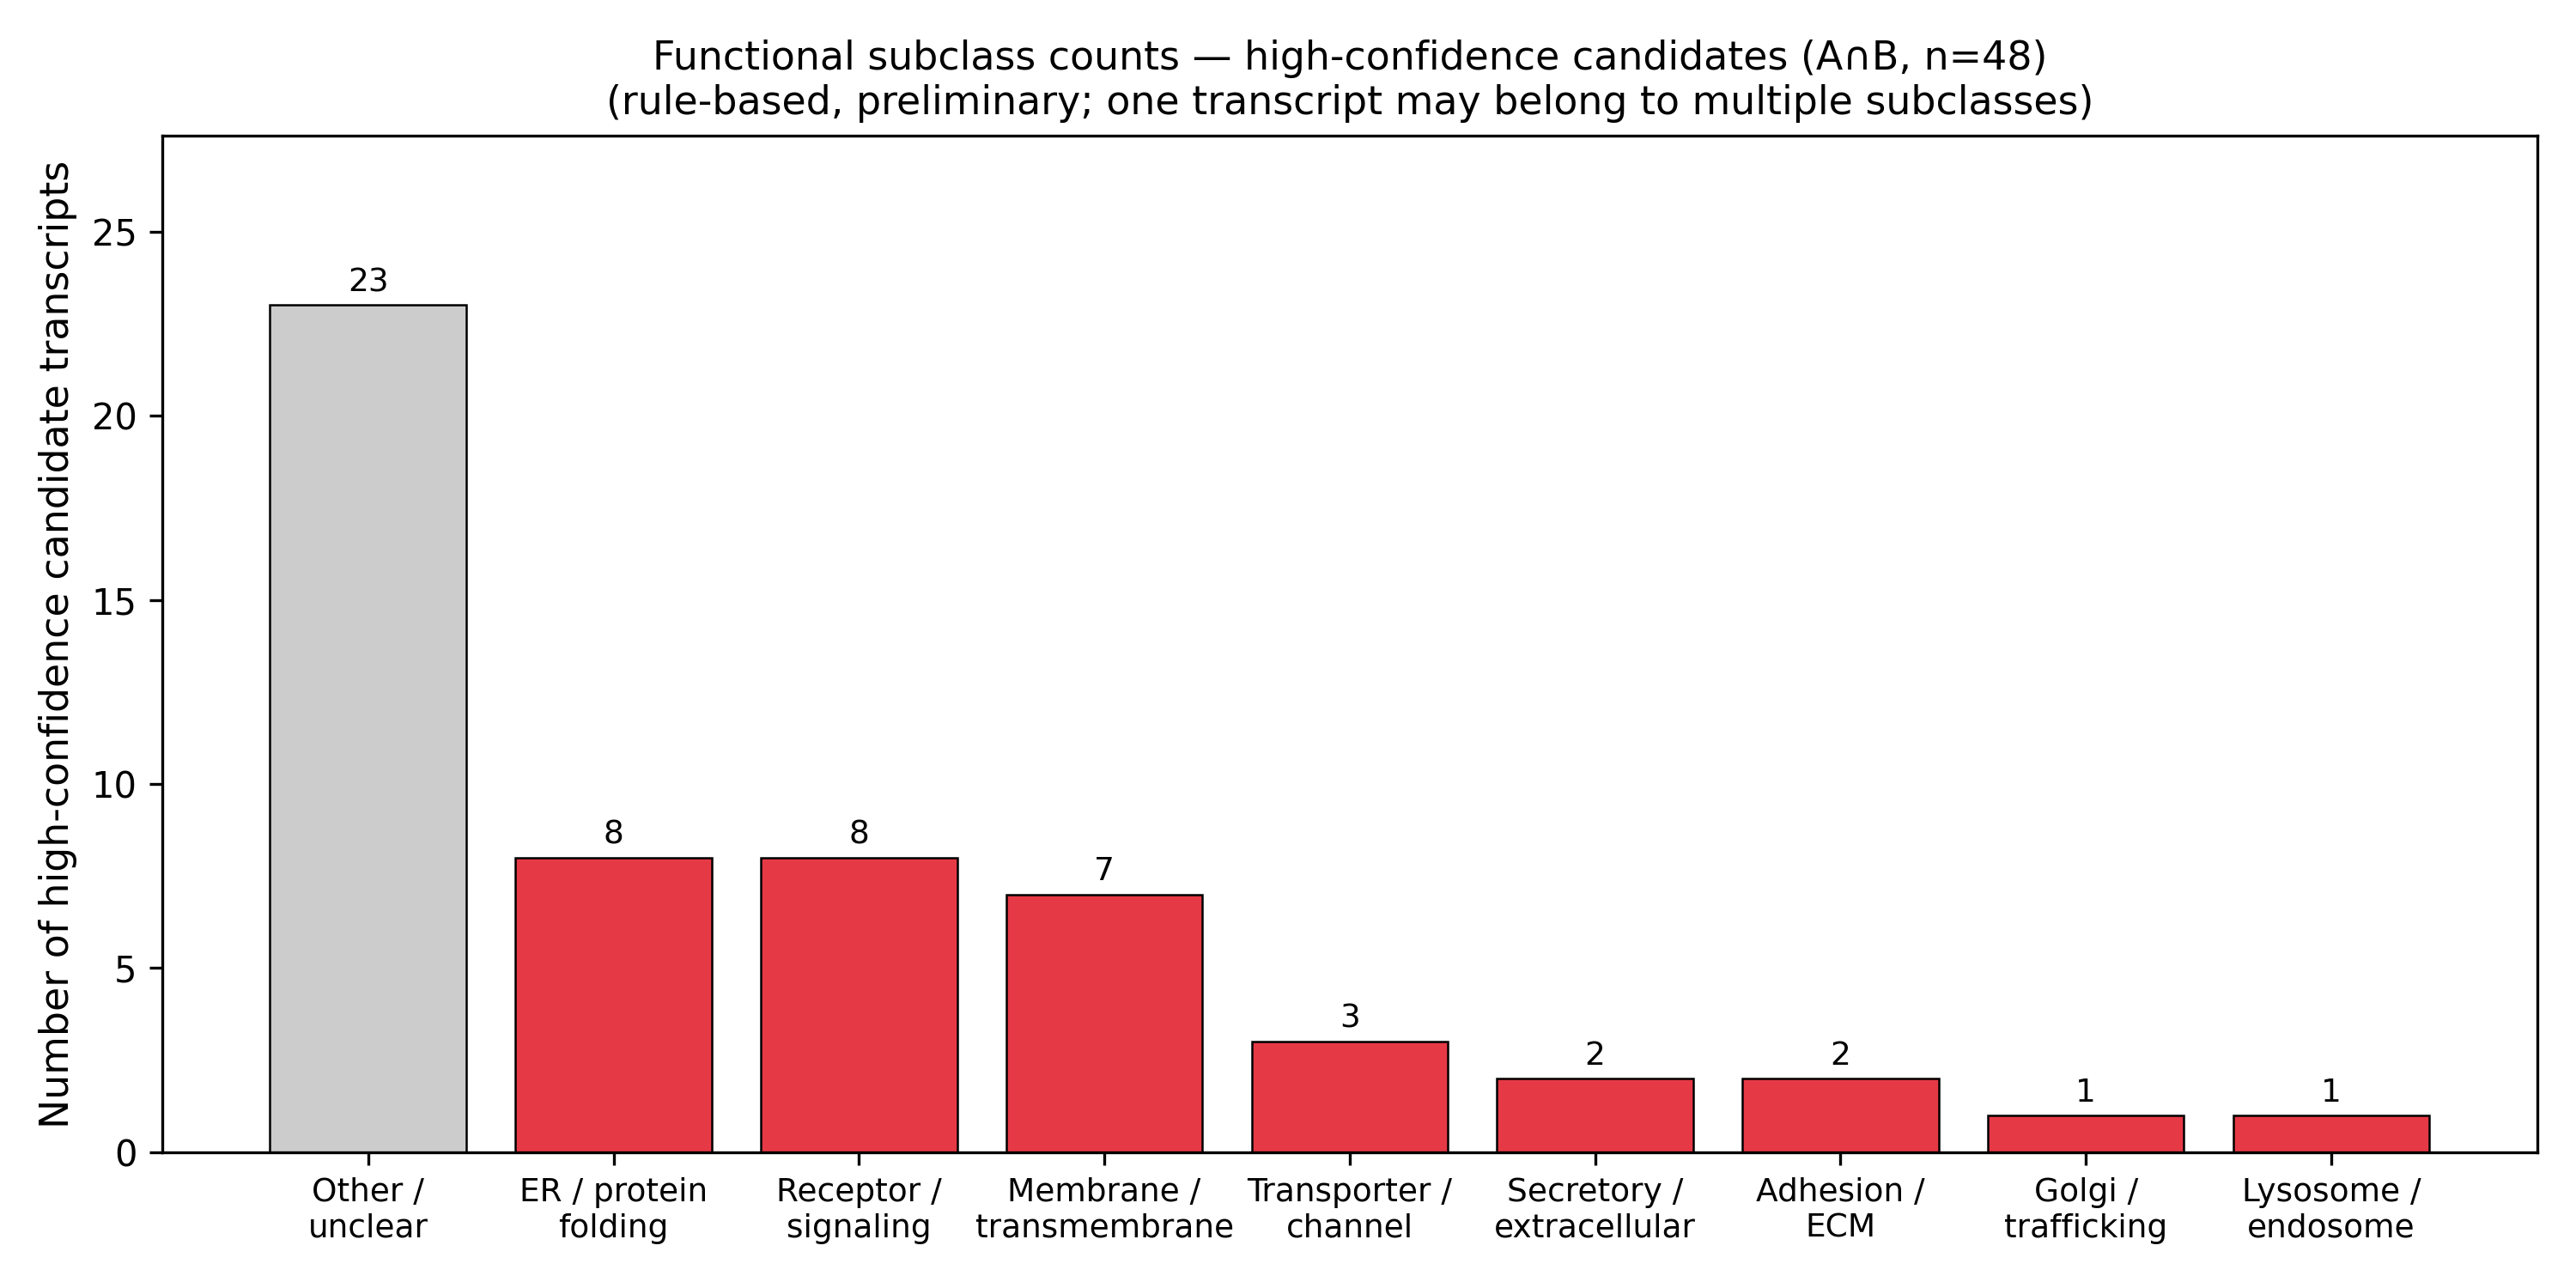

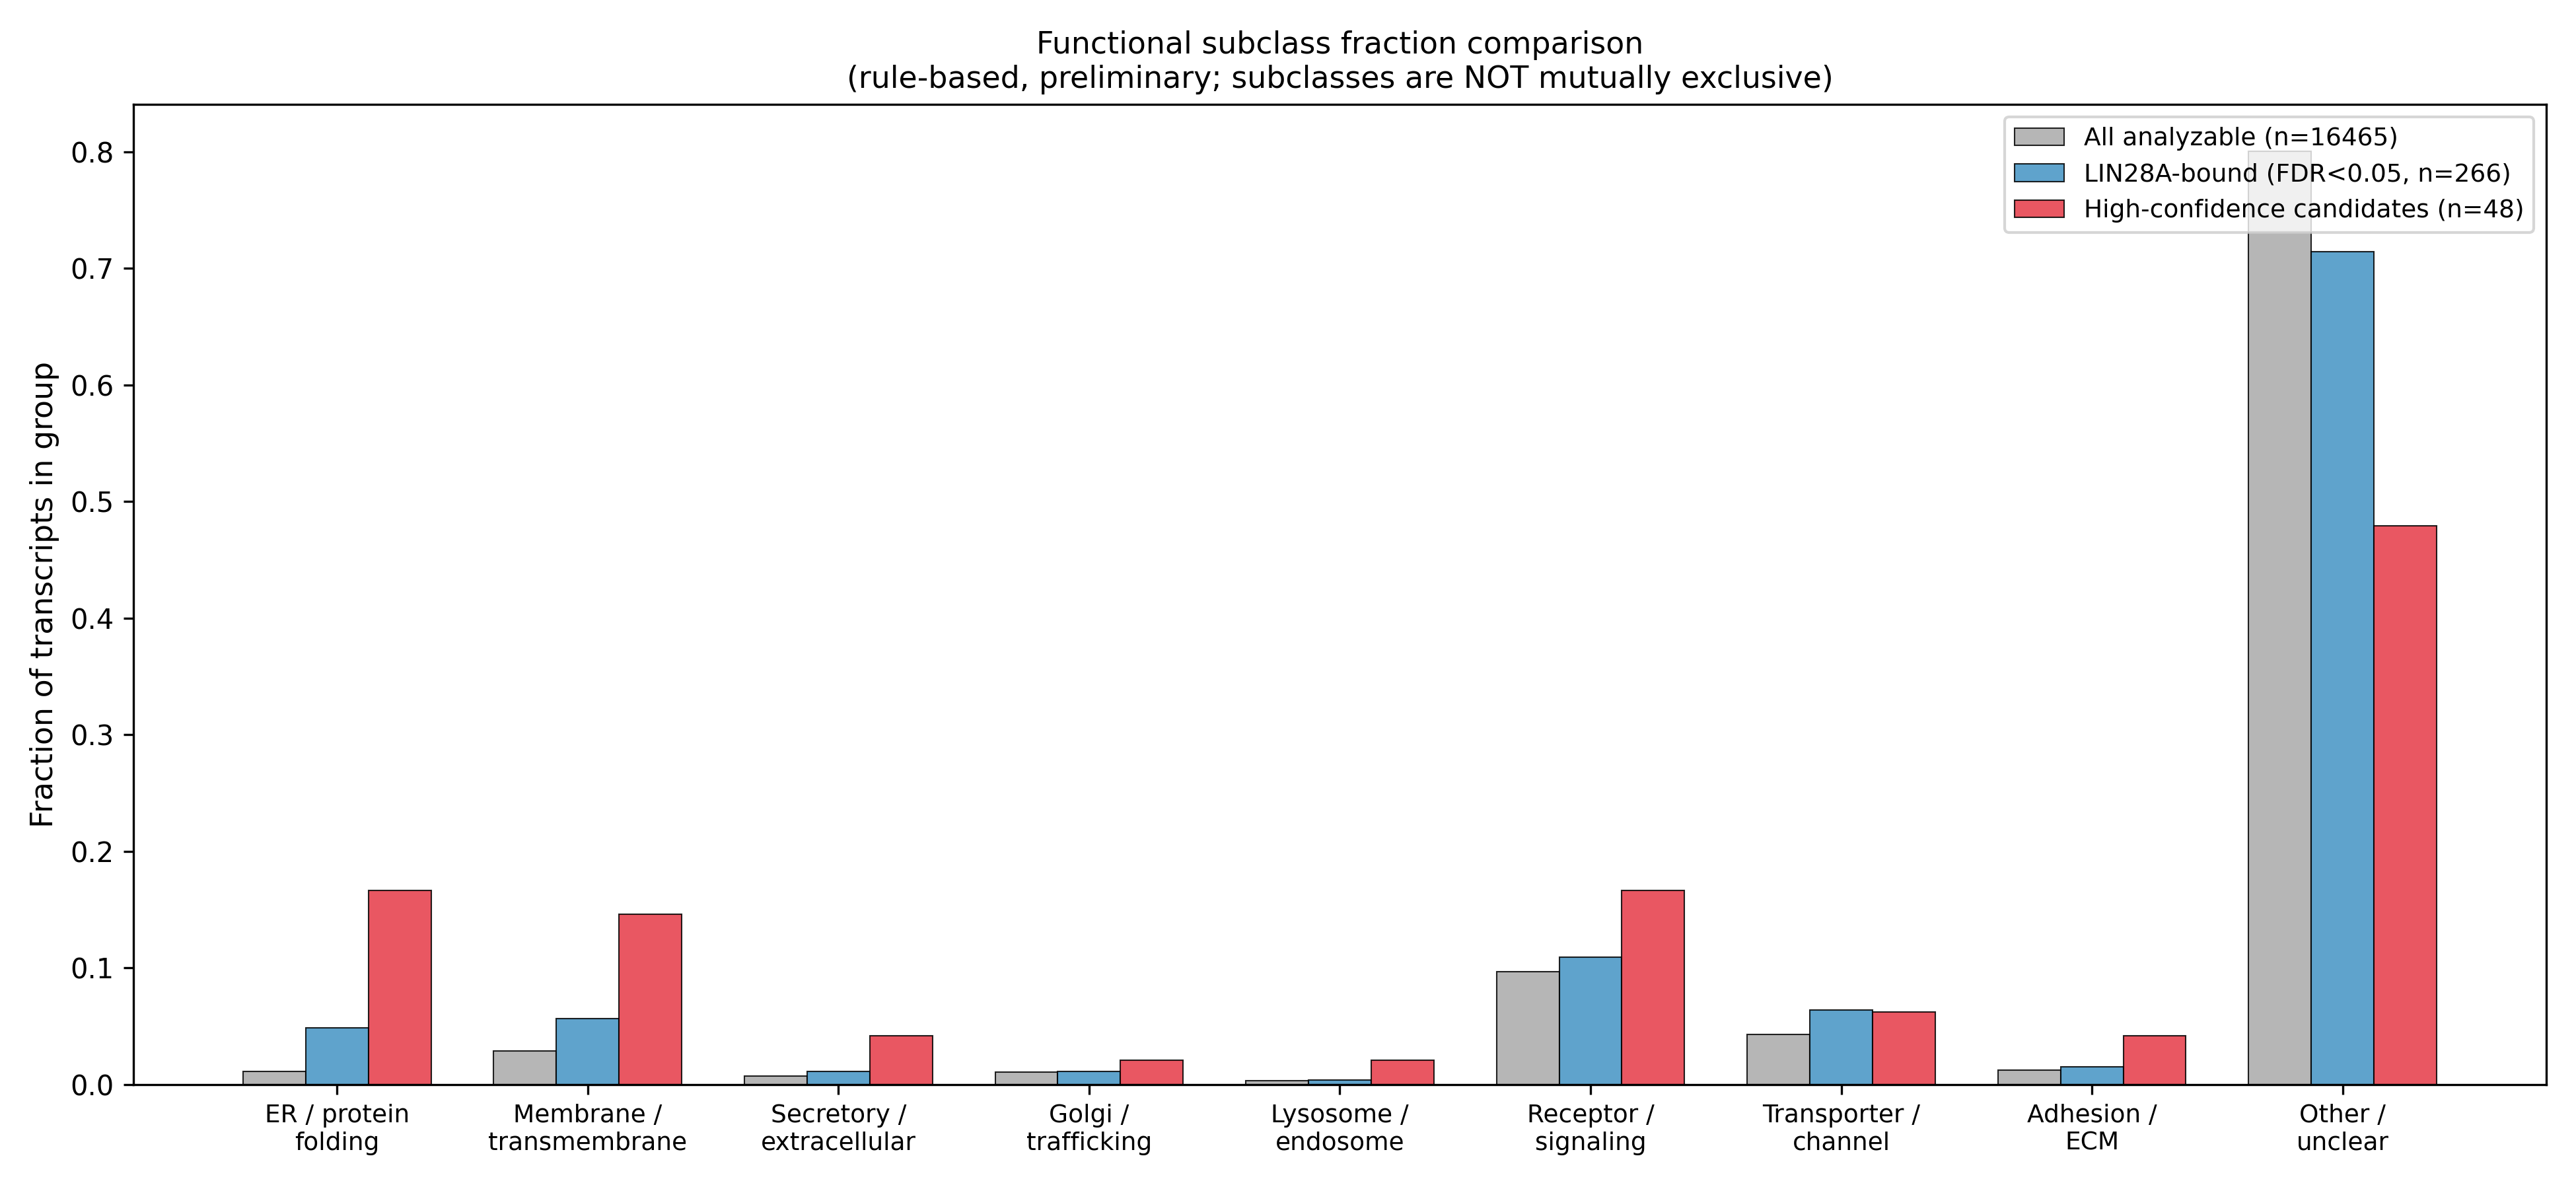

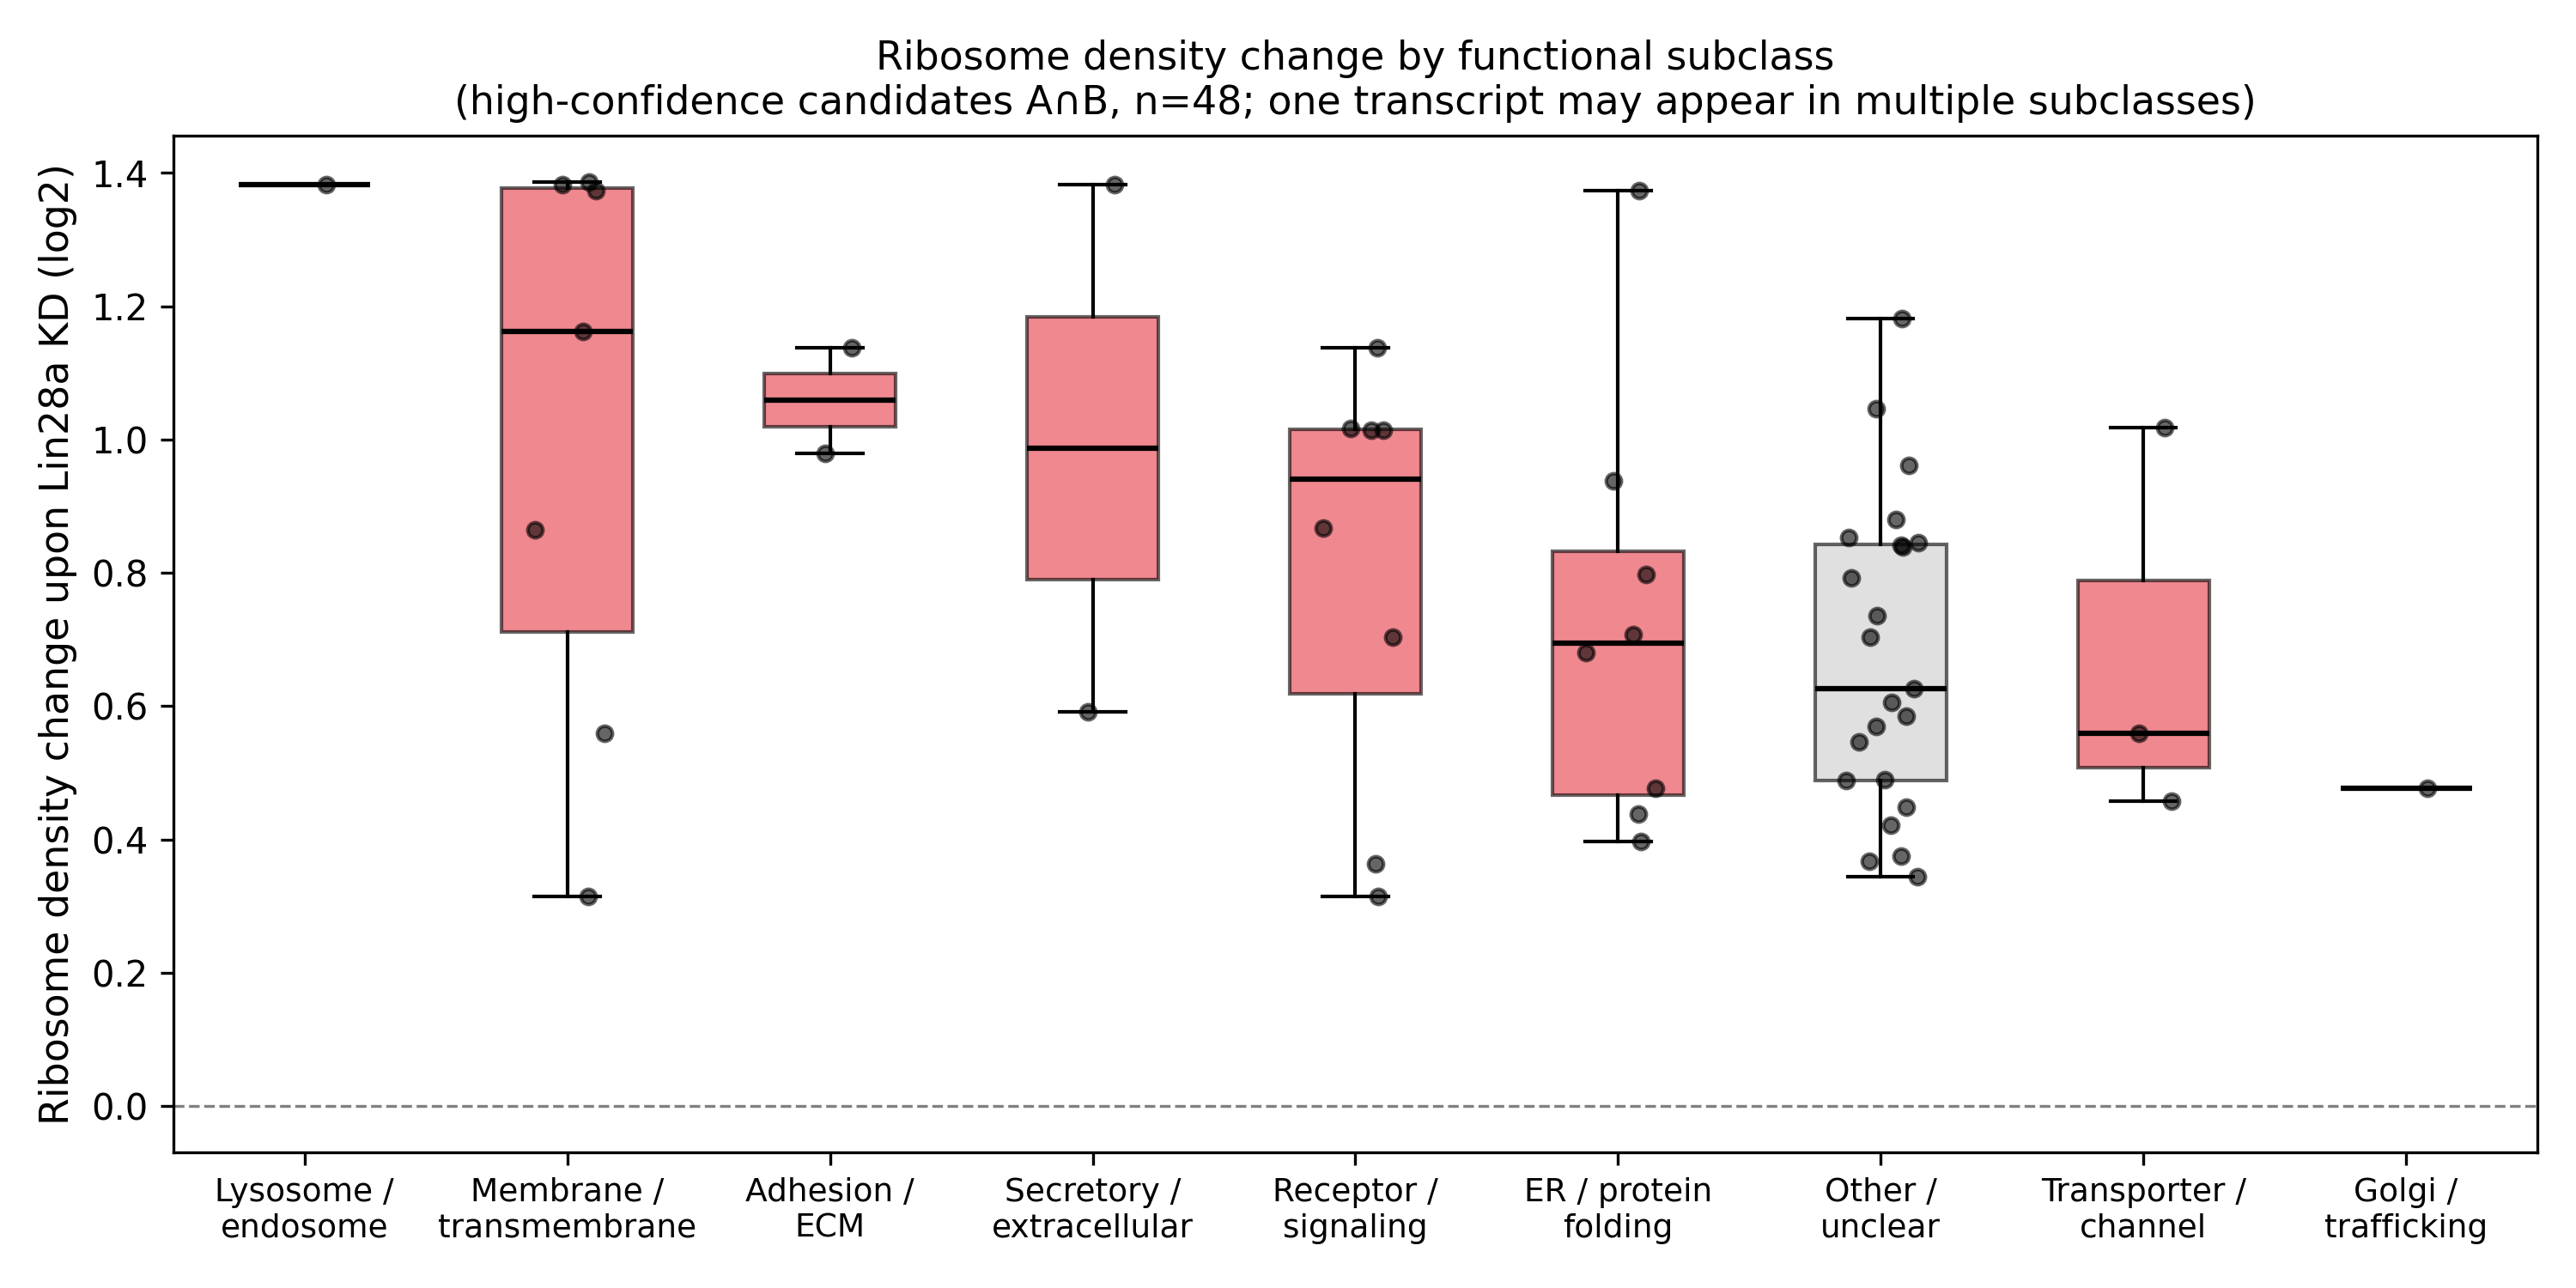

In [1]:
SC_LABELS = {
    'is_ER_or_protein_folding':        'ER / protein\nfolding',
    'is_membrane_or_transmembrane':    'Membrane /\ntransmembrane',
    'is_secretory_or_extracellular':   'Secretory /\nextracellular',
    'is_Golgi_or_trafficking':         'Golgi /\ntrafficking',
    'is_lysosome_or_endosome':         'Lysosome /\nendosome',
    'is_receptor_or_signaling':        'Receptor /\nsignaling',
    'is_transporter_or_channel':       'Transporter /\nchannel',
    'is_adhesion_or_ECM':              'Adhesion /\nECM',
    'is_other_or_unclear':             'Other /\nunclear',
}

# Figure 04-1
counts_hc = {sc: int(hc_full[sc].sum()) for sc in subclass_cols}
sc_order = sorted(counts_hc, key=lambda x: counts_hc[x], reverse=True)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E63946' if 'other' not in sc else '#CCCCCC' for sc in sc_order]
bars = ax.bar([SC_LABELS[sc] for sc in sc_order],
              [counts_hc[sc] for sc in sc_order],
              color=colors, edgecolor='black', linewidth=0.6)
ax.bar_label(bars, padding=2, fontsize=9)
ax.set_ylabel('Number of high-confidence candidate transcripts', fontsize=11)
ax.set_title(
    f'Functional subclass counts — high-confidence candidates (A∩B, n={len(hc_full)})\n'
    '(rule-based, preliminary; one transcript may belong to multiple subclasses)',
    fontsize=11)
ax.set_ylim(0, max(counts_hc.values()) * 1.2)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
fig.savefig(f'{OUT_F}/04_high_confidence_subclass_counts.png', dpi=300)
plt.show()
print('Saved 04_high_confidence_subclass_counts.png')

# Figure 04-2
grp_keys = list(groups.keys())
grp_colors = ['#AAAAAA', '#4393C3', '#E63946']
x = np.arange(len(subclass_cols))
width = 0.25
fig, ax = plt.subplots(figsize=(13, 6))
for i, (grp_label, color) in enumerate(zip(grp_keys, grp_colors)):
    fracs = [df_frac[(df_frac['group']==grp_label)&(df_frac['subclass']==sc)]['fraction'].values[0]
             for sc in subclass_cols]
    ax.bar(x + i*width, fracs, width, label=grp_label.replace('\n',' '),
           color=color, edgecolor='black', linewidth=0.5, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels([SC_LABELS[sc] for sc in subclass_cols], fontsize=9)
ax.set_ylabel('Fraction of transcripts in group', fontsize=11)
ax.set_title(
    'Functional subclass fraction comparison\n'
    '(rule-based, preliminary; subclasses are NOT mutually exclusive)',
    fontsize=11)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
fig.savefig(f'{OUT_F}/04_subclass_fraction_comparison.png', dpi=300)
plt.show()
print('Saved 04_subclass_fraction_comparison.png')

# Figure 04-3
ribo_by_sc = {}
for sc in subclass_cols:
    vals = hc_full.loc[hc_full[sc] == True, ribo_col].dropna().values
    if len(vals) > 0:
        ribo_by_sc[sc] = vals
sc_order3 = sorted([sc for sc in subclass_cols if sc in ribo_by_sc],
                   key=lambda sc: np.median(ribo_by_sc[sc]), reverse=True)
fig, ax = plt.subplots(figsize=(10, 5))
for pos, sc in enumerate(sc_order3):
    vals = ribo_by_sc[sc]
    color = '#E63946' if 'other' not in sc else '#CCCCCC'
    ax.boxplot(vals, positions=[pos], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=1.5),
               whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1),
               flierprops=dict(marker='o', markersize=3, alpha=0.5))
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(vals))
    ax.scatter(np.full(len(vals), pos) + jitter, vals, c='black', alpha=0.6, s=18, zorder=4)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks(list(range(len(sc_order3))))
ax.set_xticklabels([SC_LABELS[sc] for sc in sc_order3], fontsize=9)
ax.set_ylabel('Ribosome density change upon Lin28a KD (log2)', fontsize=11)
ax.set_title(
    f'Ribosome density change by functional subclass\n'
    f'(high-confidence candidates A∩B, n={len(hc_full)}; one transcript may appear in multiple subclasses)',
    fontsize=11)
plt.tight_layout()
fig.savefig(f'{OUT_F}/04_ribosome_change_by_subclass.png', dpi=300)
plt.show()
print('Saved 04_ribosome_change_by_subclass.png')


## 8. Spec 05 input table

In [ ]:
spec05_cols = ['Accession','Gene Symbol','Description',
               clip_col, fdr_col, ribo_col, rna_col] + subclass_cols
df_spec05 = hc_full[spec05_cols].sort_values(
    by=[clip_col, ribo_col], ascending=[False, False]).copy()
df_spec05.to_csv(f'{OUT_T}/04_high_confidence_candidates_for_spec05.csv', index=False)
print(f'Saved 04_high_confidence_candidates_for_spec05.csv ({len(df_spec05)} rows)')
